In [0]:
display(dbutils.fs.ls("dbfs:/Workspace/"))


path,name,size,modificationTime
dbfs:/Workspace/.rm-rf-guard,.rm-rf-guard,0,1780291304055
dbfs:/Workspace/Repos/,Repos/,4096,1780293541844
dbfs:/Workspace/Shared/,Shared/,4096,1780293541844
dbfs:/Workspace/Users/,Users/,4096,1780293541844


In [0]:
df = spark.read.csv(
    "file:/Workspace/Users/gomathilakshmigandhi@gmail.com/Medical_Insurance_Prediction/insurance.csv",
    header=True,
    inferSchema=True
)

display(df)

age,sex,bmi,children,smoker,region,charges
19,female,27.9,0,yes,southwest,16884.924
18,male,33.77,1,no,southeast,1725.5523
28,male,33.0,3,no,southeast,4449.462
33,male,22.705,0,no,northwest,21984.47061
32,male,28.88,0,no,northwest,3866.8552
31,female,25.74,0,no,southeast,3756.6216
46,female,33.44,1,no,southeast,8240.5896
37,female,27.74,3,no,northwest,7281.5056
37,male,29.83,2,no,northeast,6406.4107
60,female,25.84,0,no,northwest,28923.13692


In [0]:
df.printSchema()
print("Rows: ",df.count())
print("Columns: ",len(df.columns))
display(df.describe())

root
 |-- age: integer (nullable = true)
 |-- sex: string (nullable = true)
 |-- bmi: double (nullable = true)
 |-- children: integer (nullable = true)
 |-- smoker: string (nullable = true)
 |-- region: string (nullable = true)
 |-- charges: double (nullable = true)

Rows:  1338
Columns:  7


summary,age,sex,bmi,children,smoker,region,charges
count,1338,1338,1338,1338,1338,1338,1338
mean,39.20702541106129,null,30.663396860986538,1.0949177877429,null,null,13270.422265141257
stddev,14.049960379216172,null,6.098186911679017,1.2054927397819095,null,null,12110.011236693994
min,18,female,15.96,0,no,northeast,1121.8739
max,64,male,53.13,5,yes,southwest,63770.42801


In [0]:
train_data.printSchema()

---------------------------------------------------------------------------
NameError                                 Traceback (most recent call last)
File <command-5294040416910547>, line 1
----> 1 train_data.printSchema()

NameError: name 'train_data' is not defined

In [0]:
from pyspark.sql.functions import avg

df.select(avg("charges").alias("Average_Charge")).show()

+------------------+
|    Average_Charge|
+------------------+
|13270.422265141257|
+------------------+



In [0]:
df.groupBy("smoker").avg("charges").show()

+------+-----------------+
|smoker|     avg(charges)|
+------+-----------------+
|   yes|32050.23183153285|
|    no|8434.268297856199|
+------+-----------------+



In [0]:
from pyspark.sql.functions import corr
df.select(
    corr("age", "charges").alias("Age_Charges_Correlation")
).show()

+-----------------------+
|Age_Charges_Correlation|
+-----------------------+
|      0.299008193330648|
+-----------------------+



In [0]:
from pyspark.sql.functions import corr

df.select(
    corr("bmi", "charges").alias("BMI_Charges_Correlation")
).show()

+-----------------------+
|BMI_Charges_Correlation|
+-----------------------+
|    0.19834096883362903|
+-----------------------+



In [0]:
region_charges = df.groupBy("region").avg("charges")

region_charges = region_charges.withColumnRenamed(
    "avg(charges)",
    "Average_Charge"
)

region_charges.orderBy(
    "Average_Charge",
    ascending=False
).show()

+---------+------------------+
|   region|    Average_Charge|
+---------+------------------+
|southeast|14735.411437609895|
|northeast|  13406.3845163858|
|northwest|12417.575373969228|
|southwest| 12346.93737729231|
+---------+------------------+



In [0]:
gender_charges = df.groupBy("sex").avg("charges")

gender_charges = gender_charges.withColumnRenamed(
    "avg(charges)",
    "Average_Charge"
)

gender_charges.show()

+------+------------------+
|   sex|    Average_Charge|
+------+------------------+
|  male|13956.751177721886|
|female| 12569.57884383534|
+------+------------------+



In [0]:
children_charges = df.groupBy("children").avg("charges")

children_charges = children_charges.withColumnRenamed(
    "avg(charges)",
    "Average_Charge"
)

children_charges.orderBy("children").show()

+--------+------------------+
|children|    Average_Charge|
+--------+------------------+
|       0|12365.975601635882|
|       1|12731.171831635793|
|       2|15073.563733958328|
|       3| 15355.31836681528|
|       4|13850.656311199999|
|       5| 8786.035247222222|
+--------+------------------+



In [0]:
display(df.describe())

summary,age,sex,bmi,children,smoker,region,charges
count,1338,1338,1338,1338,1338,1338,1338
mean,39.20702541106129,null,30.663396860986538,1.0949177877429,null,null,13270.422265141257
stddev,14.049960379216172,null,6.098186911679017,1.2054927397819095,null,null,12110.011236693994
min,18,female,15.96,0,no,northeast,1121.8739
max,64,male,53.13,5,yes,southwest,63770.42801


In [0]:
from pyspark.sql.functions import col, when, count

df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+---+---+---+--------+------+------+-------+
|age|sex|bmi|children|smoker|region|charges|
+---+---+---+--------+------+------+-------+
|  0|  0|  0|       0|     0|     0|      0|
+---+---+---+--------+------+------+-------+



In [0]:
import matplotlib.pyplot as plt

pdf = df.toPandas()

print(pdf.head())

   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520


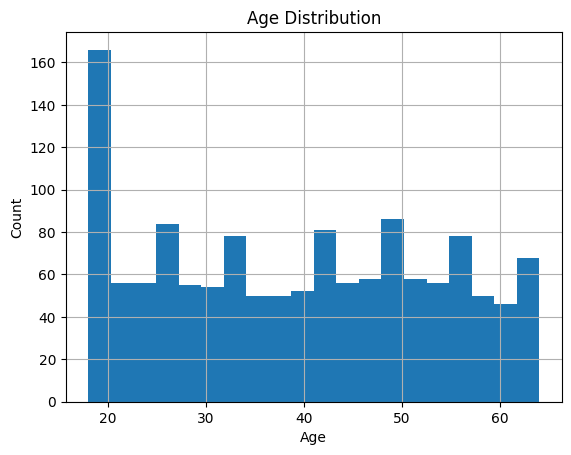

In [0]:
import matplotlib.pyplot as plt

pdf["age"].hist(bins=20)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

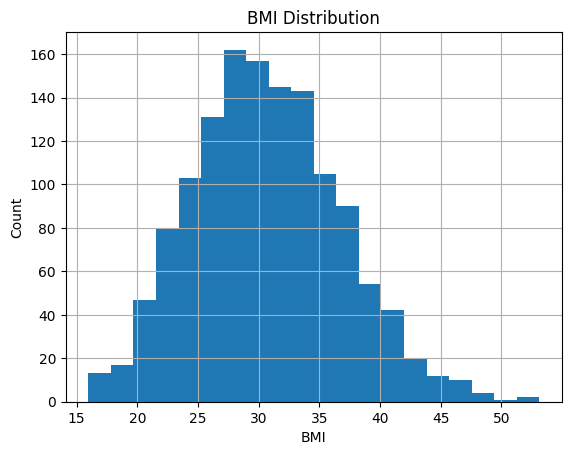

In [0]:
import matplotlib.pyplot as plt

pdf["bmi"].hist(bins=20)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")
plt.show()

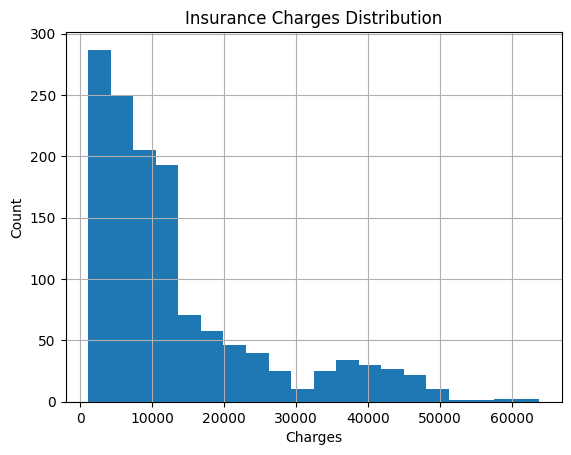

In [0]:
import matplotlib.pyplot as plt

pdf["charges"].hist(bins=20)

plt.title("Insurance Charges Distribution")
plt.xlabel("Charges")
plt.ylabel("Count")
plt.show()

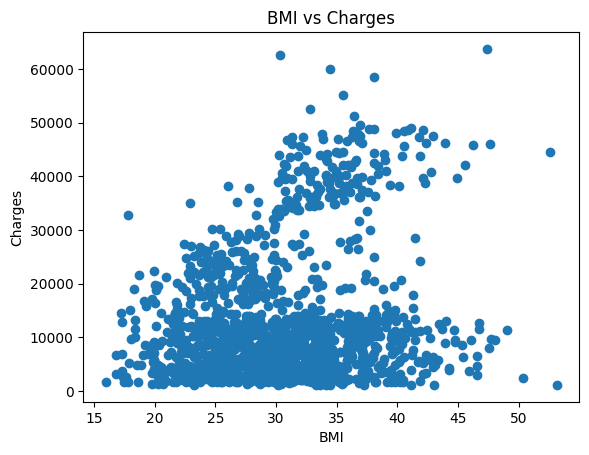

In [0]:
import matplotlib.pyplot as plt

plt.scatter(pdf["bmi"], pdf["charges"])

plt.title("BMI vs Charges")
plt.xlabel("BMI")
plt.ylabel("Charges")
plt.show()

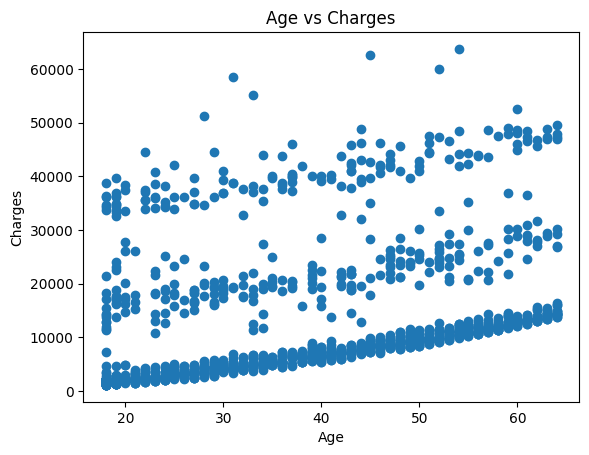

In [0]:
import matplotlib.pyplot as plt

plt.scatter(pdf["age"], pdf["charges"])

plt.title("Age vs Charges")
plt.xlabel("Age")
plt.ylabel("Charges")
plt.show()

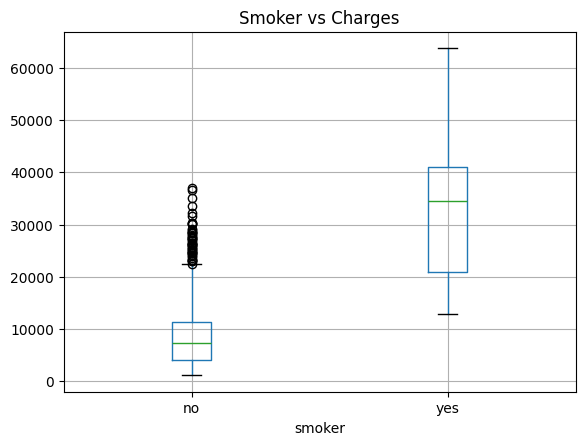

In [0]:
import matplotlib.pyplot as plt

pdf.boxplot(column="charges", by="smoker")

plt.title("Smoker vs Charges")
plt.suptitle("")
plt.show()

# Medical Insurance Premium Prediction

## Week 1 Summary Report

### Objective
Predict insurance premiums based on customer characteristics.

### Dataset Information
- Dataset: Medical Cost Personal Dataset
- Total Records: 1338
- Features: 7
- Target Variable: charges

### Features
1. age
2. sex
3. bmi
4. children
5. smoker
6. region
7. charges

### Key Insights

- Smoking has the highest impact on insurance charges.
- Older customers generally pay higher premiums.
- BMI moderately influences charges.
- Most customers have charges below 15000.
- Region has less impact compared to smoking and age.

### Visualizations Created

- Age Distribution
- BMI Distribution
- Charges Distribution
- BMI vs Charges
- Age vs Charges
- Smoker vs Charges

### Conclusion

The dataset is clean and suitable for machine learning. Smoking status, age, and BMI appear to be the most important factors affecting insurance premiums.